In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from ranking import (load_all_multi, compute_scores,
                     print_ranking_table, extract_ranked_arrays, pareto_front,
                     compute_subset_rankings,
                     print_cross_snapshot_table, print_cross_mass_table,
                     print_cross_snap_mass_table, print_function_inspector,
                     load_function_params)

%load_ext autoreload
%autoreload 2
%matplotlib inline

# Density Profile Model Ranking

Load fitting results from multiple snapshots and rank candidate functions by cross-entropy (CE) and BIC. The notebook is organised into sections:

1. **Setup & data loading** — load particle metadata and HDF5 result files
2. **Filtering & scoring** — apply mass/parameter cuts, compute overall ranking
3. **Overall ranking** — top functions per complexity and merged
4. **Pareto front** — complexity vs CE/BIC trade-off
5. **Subset rankings** — how ranks change across snapshots, mass bins, and their combination
6. **Function inspector** — detailed view of a single candidate function

In [5]:
# --- Load everything once ---
data = load_all_multi(
    particle_files=[
        Path("../data/tng_particles/particles_099.hdf5"),
        Path("../data/tng_particles/particles_050.hdf5"),
        Path("../data/tng_particles/particles_033.hdf5"),
        ],
    results_dir=Path("../results"),
    result_patterns=[
        "fit_ext_maths_DM_compl{comp}_particles_099.hdf5",
        "fit_ext_maths_DM_compl{comp}_particles_050.hdf5",
        "fit_ext_maths_DM_compl{comp}_particles_033.hdf5",
        ],
    complexities=[4, 5, 6, 7],
    reweight_snapshots=True,
)

Loaded 904 halos from particles_099.hdf5
  M200c range: 1.00e+12 - 6.70e+13 Msun/h
  compl4: 30736 results, 34 functions
  compl5: 232958 results, 261 functions
  compl6: 1737422 results, 1973 functions
  compl7: 13654254 results, 15728 functions
Loaded 187 halos from particles_050.hdf5
  M200c range: 1.00e+12 - 2.82e+13 Msun/h
  compl4: 6358 results, 34 functions
  compl5: 48410 results, 263 functions
  compl6: 361790 results, 2004 functions
  compl7: 2857178 results, 16047 functions
Loaded 61 halos from particles_033.hdf5
  M200c range: 1.00e+12 - 4.47e+13 Msun/h
  compl4: 2140 results, 36 functions
  compl5: 16481 results, 277 functions
  compl6: 125180 results, 2138 functions
  compl7: 990810 results, 17115 functions
  Snapshot reweighting enabled (904, 187, 61 halos)

Combined: 1152 halos from 3 files


In [6]:
# --- Mass filter & scoring (re-run this cell to change cuts) ---
min_mass = None   # e.g. 1e13 [Msun/h], None = no cut
max_mass = None    # e.g. 1e14 [Msun/h], None = no cut
max_params = 3 # e.g. 3 to keep only functions with k <= 3, None = no cut
n_top = 30

halo_mask = np.ones(data["n_halos"], dtype=bool)
if min_mass is not None:
    halo_mask &= data["M200c"] >= min_mass
if max_mass is not None:
    halo_mask &= data["M200c"] <= max_mass

print(f"Halos selected: {halo_mask.sum()}/{data['n_halos']}")
if min_mass is not None or max_mass is not None:
    sel = data["M200c"][halo_mask]
    print(f"  M200c range: {sel.min():.2e} - {sel.max():.2e} "
          f"{data['units_M200c']}")

scores, ranked = compute_scores(
    data, halo_mask=halo_mask,
    min_success_fraction=0.5,
    failure_loss_percentile=95)

# Optional parameter cut.
if max_params is not None:
    ranked = [r for r in ranked if r[4] <= max_params]
    print(f"Parameter cut: k <= {max_params}")

print(f"Functions ranked: {len(ranked)}")

Halos selected: 1152/1152
Parameter cut: k <= 3
Functions ranked: 17353


## Filtering & scoring

Apply optional mass and parameter cuts, then compute the overall CE/BIC ranking across all halos. Re-run this cell to change cuts.

In [7]:
# --- Ranking tables ---
# Per-complexity tables
for comp in data["complexities"]:
    comp_ranked = [r for r in ranked if r[0] == comp]
    print_ranking_table(
        comp_ranked, data["equations"],
        f"COMPLEXITY {comp}",
        n_top=n_top, nfw_score=data["nfw_scores"].get(comp))
    print()

NFW REFERENCE: CE = 8.037535, Delta_CE = 0.000734
----------------------------------------------------------------------------------------------------

COMPLEXITY 4
Rank   Comp   Func#   CE           Delta_CE     dBIC       k    #Halo   Equation
----------------------------------------------------------------------------------------------------
1      4      96      8.036801     0.000000     0.0        2    1152    pow((x + 1),a0)
2      4      67      8.068142     0.031341     626.8      2    1152    pow(x,(a0 + 1))
3      4      139     8.068142     0.031341     626.8      2    1152    pow(x,a0)
4      4      263     8.069313     0.032512     650.2      2    1152    pow(Abs(a0),(sqrt(x)))
5      4      98      8.069313     0.032512     641.0      1    1152    exp(-sqrt(x))
6      4      202     8.074105     0.037304     736.9      1    1152    1/(x**2 + 1)
7      4      188     8.077016     0.040215     795.1      1    1152    (x + 1)**(-2)
8      4      145     8.078978     0.042177

## Overall ranking

Top functions ranked by CE, shown per complexity level and merged across all complexities.

In [5]:
# Merged table
print_ranking_table(
    ranked, data["equations"],
    "ALL COMPLEXITIES MERGED",
    n_top=n_top)


ALL COMPLEXITIES MERGED
Rank   Comp   Func#   CE           Delta_CE     dBIC       k    #Halo   Equation
----------------------------------------------------------------------------------------------------
1      7      22769   8.034778     0.000000     0.0        3    1152    pow(Abs(a0),(pow(x,(a1 + x))))
2      7      70679   8.034862     0.000084     1.7        3    1152    pow((x + pow(Abs(a0),x)),a1)
3      7      8051    8.034922     0.000143     2.9        3    1152    pow(Abs(a0 - x),(a1 - x))
4      7      8498    8.034935     0.000157     3.1        3    1152    pow((x + pow(x,a0)),a1)
5      7      24470   8.034985     0.000206     4.1        3    1152    pow(Abs(a0 - exp(x/2)),a1)
6      7      21916   8.034990     0.000211     4.2        3    1152    pow(Abs(a0 + exp(x/2)),a1)
7      7      9814    8.034993     0.000215     4.3        3    1152    pow(Abs(exp(x) - Abs(a0)),a1)
8      7      11608   8.034995     0.000217     4.3        3    1152    pow(Abs(a0 - exp(x)),(a

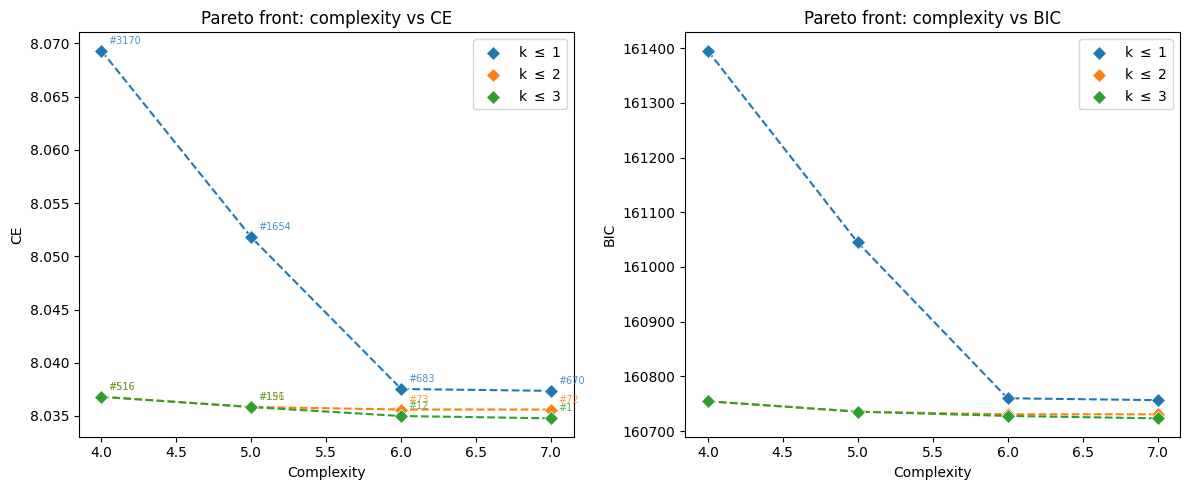


Pareto-optimal functions by CE, k <= 1 (4):
k    CE           Comp   Equation
--------------------------------------------------------------------------------
1    8.069313     4      exp(-sqrt(x))
1    8.051781     5      -x + x**(-2)
1    8.037535     6      1/(x*(x + 1)**2)
1    8.037361     7      pow(x,(-pow(x,(1/8))))

Pareto-optimal functions by CE, k <= 2 (4):
k    CE           Comp   Equation
--------------------------------------------------------------------------------
2    8.036801     4      pow((x + 1),a0)
2    8.035849     5      pow((sqrt(x) + 1),a0)
2    8.035608     6      pow((x + 1),a0)/x
2    8.035608     7      1/(x*pow((x + 1),a0))

Pareto-optimal functions by CE, k <= 3 (4):
k    CE           Comp   Equation
--------------------------------------------------------------------------------
2    8.036801     4      pow((x + 1),a0)
3    8.035834     5      pow(Abs(a0),(pow(x,a1)))
3    8.034996     6      pow(Abs(a0 - exp(x)),a1)
3    8.034778     7      pow(Abs(a

In [6]:
# --- Pareto front by max number of free parameters ---
# Use unfiltered ranked list (recompute without k cut)
_, ranked_all = compute_scores(
    data, halo_mask=halo_mask,
    min_success_fraction=0.5,
    failure_loss_percentile=95)

arr = extract_ranked_arrays(ranked_all)
comps, ces, bics, ks = arr["comps"], arr["ces"], arr["bics"], arr["ks"]

max_k_values = [1, 2, 3]
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

eqs = data["equations"]

for ax, vals, label in [
    (axes[0], ces, "CE"),
    (axes[1], bics, "BIC"),
]:
    for max_k, color in zip(max_k_values, colors):
        mask_k = ks <= max_k
        if mask_k.sum() == 0:
            continue

        pareto = pareto_front(comps[mask_k], vals[mask_k])
        full_idx = np.where(mask_k)[0]
        pareto_idx = full_idx[pareto]
        pareto_idx_sorted = pareto_idx[np.argsort(comps[pareto_idx])]

        ax.plot(comps[pareto_idx_sorted], vals[pareto_idx_sorted],
                '--', color=color, lw=1.5, zorder=5)
        ax.scatter(comps[pareto_idx_sorted], vals[pareto_idx_sorted],
                   c=color, s=50, zorder=6, marker='D',
                   edgecolors='white', linewidths=0.5,
                   label=f'k $\\leq$ {max_k}')

        # Label Pareto-optimal points with overall rank
        if label == "CE":
            for pi in pareto_idx_sorted:
                comp_i, fidx_i = ranked_all[pi][0], ranked_all[pi][1]
                for ri, r in enumerate(ranked_all, 1):
                    if r[0] == comp_i and r[1] == fidx_i:
                        break
                ax.annotate(f"#{ri}", (comps[pi], vals[pi]),
                            textcoords="offset points", xytext=(5, 5),
                            fontsize=7, color=color, alpha=0.8)

    ax.set_xlabel('Complexity')
    ax.set_ylabel(label)
    ax.set_title(f'Pareto front: complexity vs {label}')
    ax.legend()

plt.tight_layout()
plt.show()

# Print Pareto-optimal functions per k cut (CE front)
for max_k in max_k_values:
    mask_k = ks <= max_k
    if mask_k.sum() == 0:
        continue
    pareto = pareto_front(comps[mask_k], ces[mask_k])
    full_idx = np.where(mask_k)[0]
    pareto_idx = full_idx[pareto]
    pareto_idx = pareto_idx[np.argsort(comps[pareto_idx])]

    print(f"\nPareto-optimal functions by CE, k <= {max_k} ({len(pareto_idx)}):")
    print(f"{'k':<4} {'CE':<12} {'Comp':<6} Equation")
    print("-" * 80)
    for i in pareto_idx:
        comp, fidx, ce, bic_, k, _ = ranked_all[i]
        eq = eqs[comp][fidx]
        if len(eq) > 50:
            eq = eq[:47] + "..."
        print(f"{k:<4} {ce:<12.6f} {comp:<6} {eq}")

## Pareto front

Complexity vs CE/BIC trade-off. Separate Pareto curves for k &le; 1, 2, 3. Points are labelled with overall rank.

In [9]:
# --- Compute subset rankings ---
score_kwargs = dict(min_success_fraction=0.5, failure_loss_percentile=95)
mass_edges = np.array([1e12, 10**12.5, 1e13, np.inf])
snap_labels = ["z=0 (099)", "z=1 (050)", "z=2 (033)"]

subset = compute_subset_rankings(
    data, mass_edges, halo_mask=halo_mask, **score_kwargs)

## Subset rankings

How does a function's rank change when restricting to a single snapshot, a single mass bin, or a specific (snapshot, mass bin) cell? Each table shows the **rank within that subset** and the **dCE** to the best function in that subset.

- **By snapshot** — is the function good at all redshifts?
- **By mass bin** — is it good across all halo masses?
- **By snapshot x mass bin** — the full 2D breakdown for each top function

In [8]:
# --- Ranking by snapshot ---
print_cross_snapshot_table(ranked, data, subset, n_top=n_top,
                           snap_labels=snap_labels)


RANKING BY SNAPSHOT (rank within snapshot, dCE to best)
Rank   CE           z=0 (099)     z=1 (050)     z=2 (033)     k    Equation
------------------------------------------------------------------------------------------------------
1      8.034778     #1     +0.0000 #1     +0.0000 #3     +0.0000 3    pow(Abs(a0),(pow(x,(a1 + x))))
2      8.034862     #24    +0.0002 #2     +0.0001 #1     +0.0000 3    pow((x + pow(Abs(a0),x)),a1)
3      8.034922     #22    +0.0001 #4     +0.0002 #4     +0.0001 3    pow(Abs(a0 - x),(a1 - x))
4      8.034935     #25    +0.0002 #7     +0.0003 #2     +0.0000 3    pow((x + pow(x,a0)),a1)
5      8.034985     #4     +0.0001 #11    +0.0003 #7     +0.0003 3    pow(Abs(a0 - exp(x/2)),a1)
6      8.034990     #14    +0.0001 #13    +0.0003 #9     +0.0003 3    pow(Abs(a0 + exp(x/2)),a1)
7      8.034993     #5     +0.0001 #12    +0.0003 #17    +0.0003 3    pow(Abs(exp(x) - Abs(a0)),a1)
8      8.034995     #6     +0.0001 #14    +0.0003 #16    +0.0003 3    pow(Abs(a0

In [9]:
# --- Ranking by mass bin ---
print_cross_mass_table(ranked, data, subset, mass_edges, n_top=n_top)


RANKING BY MASS BIN (rank within bin, dCE to best)
Rank   CE           [1.0e+12,3.2e+12)  [3.2e+12,1.0e+13)  [1.0e+13,inf)      k    Equation
---------------------------------------------------------------------------------------------------------------------
1      8.034778     #1     +0.0000 #2     +0.0000 #12    +0.0691 3    pow(Abs(a0),(pow(x,(a1 + x))))
2      8.034862     #2     +0.0000 #28    +0.0003 #17    +0.0693 3    pow((x + pow(Abs(a0),x)),a1)
3      8.034922     #3     +0.0001 #24    +0.0002 #20    +0.0693 3    pow(Abs(a0 - x),(a1 - x))
4      8.034935     #7     +0.0002 #1     +0.0000 #10    +0.0689 3    pow((x + pow(x,a0)),a1)
5      8.034985     #8     +0.0002 #9     +0.0002 #15    +0.0693 3    pow(Abs(a0 - exp(x/2)),a1)
6      8.034990     #9     +0.0002 #17    +0.0002 #16    +0.0693 3    pow(Abs(a0 + exp(x/2)),a1)
7      8.034993     #10    +0.0002 #6     +0.0002 #22    +0.0693 3    pow(Abs(exp(x) - Abs(a0)),a1)
8      8.034995     #11    +0.0002 #8     +0.0002 #23  

In [10]:
# --- Ranking by snapshot x mass bin ---
print_cross_snap_mass_table(ranked, data, subset, mass_edges, n_top=10,
                            snap_labels=snap_labels)


RANKING BY SNAPSHOT x MASS BIN (rank within cell, dCE to best)

  #1 (CE=8.034778, k=3): pow(Abs(a0),(pow(x,(a1 + x))))
                  [1.0e+12,3.2e+12)  [3.2e+12,1.0e+13)  [1.0e+13,inf)      
    z=0 (099)     #1     +0.0000 #1     +0.0000 #8     +0.0004 
    z=1 (050)     #1     +0.0000 #1     +0.0000 #5     +0.0440 
    z=2 (033)     #2     +0.0001 #20    +0.0003 #32    +0.0013 

  #2 (CE=8.034862, k=3): pow((x + pow(Abs(a0),x)),a1)
                  [1.0e+12,3.2e+12)  [3.2e+12,1.0e+13)  [1.0e+13,inf)      
    z=0 (099)     #24    +0.0002 #28    +0.0002 #246   +0.0009 
    z=1 (050)     #2     +0.0000 #2     +0.0002 #6     +0.0441 
    z=2 (033)     #1     +0.0000 #181   +0.0007 #15    +0.0011 

  #3 (CE=8.034922, k=3): pow(Abs(a0 - x),(a1 - x))
                  [1.0e+12,3.2e+12)  [3.2e+12,1.0e+13)  [1.0e+13,inf)      
    z=0 (099)     #7     +0.0001 #25    +0.0002 #197   +0.0007 
    z=1 (050)     #3     +0.0001 #7     +0.0004 #9     +0.0443 
    z=2 (033)     #7     +0.0003

In [11]:
# --- Function inspector ---
# Set inspect_rank (1-based) or inspect_expr (partial match)
# inspect_rank = 1
inspect_expr = "pow(Abs(a0),(pow(x,(a1 + x))))"

print_function_inspector(
    data, ranked, subset, mass_edges,
    rank=None,
    expr=inspect_expr,
    snap_labels=snap_labels,
)

FUNCTION INSPECTOR — Rank #1/17353
Expression : pow(Abs(a0),(pow(x,(a1 + x))))
Complexity : 7
Parameters : k = 3
CE (overall): 8.034778
BIC         : 160723.20
Halos fitted: 1152/1152

--- Per-snapshot ---
  z=0 (099)     : rank #1      CE=7.802011  dCE=0.000000
  z=1 (050)     : rank #1      CE=8.110112  dCE=0.000000
  z=2 (033)     : rank #3      CE=8.192212  dCE=0.000015

--- Per-mass-bin ---
  [1.0e+12, 3.2e+12)          : rank #1      CE=7.937837  dCE=0.000000
  [3.2e+12, 1.0e+13)          : rank #2      CE=8.335479  dCE=0.000011
  [1.0e+13, inf)              : rank #12     CE=8.755029  dCE=0.069069

--- Snapshot x mass bin ---
                [1.0e+12, 3.2e+12)  [3.2e+12, 1.0e+13)  [1.0e+13, inf)      
  z=0 (099)     #1     +0.0000 #1     +0.0000 #8     +0.0004 
  z=1 (050)     #1     +0.0000 #1     +0.0000 #5     +0.0440 
  z=2 (033)     #2     +0.0001 #20    +0.0003 #32    +0.0013 

--- Per-halo CE stats ---
  min    : 7.304466
  median : 7.808282
  max    : 9.231066
  std    

## Parameter histograms

For a chosen function and snapshot, plot histograms of the fitted parameters across all halos.

Function: pow(Abs(a0),(pow(x,(a1 + x))))
Complexity: 7, func_idx: 22769


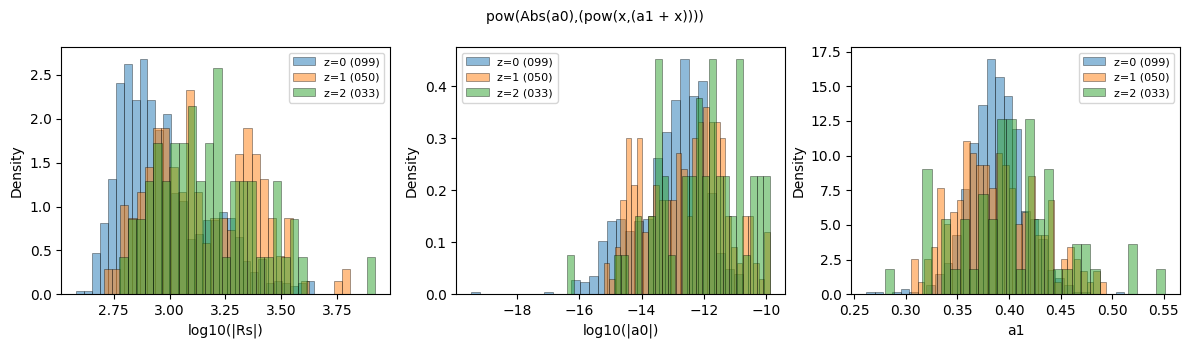

In [18]:
# --- Parameter histograms for a chosen function and snapshot ---
# Pick function by expression (partial match against equation strings)
hist_expr = "pow(Abs(a0),(pow(x,(a1 + x))))"
# Pick snapshot index (0, 1, 2, ... or None for all snapshots overlaid)
hist_snap = None
# Parameters to show in log scale (e.g. ["Rs", "a1"])
hist_log = ["Rs", "a0"]
# Whether params include Rs as first column (matches use_scaled_radius)
has_Rs = True

# Resolve function from expression
comp, fidx, eq = None, None, None
for c in data["complexities"]:
    for fi, e in enumerate(data["equations"][c]):
        if hist_expr in e:
            comp, fidx, eq = c, fi, e
            break
    if comp is not None:
        break

if comp is None:
    print(f"Expression '{hist_expr}' not found.")
else:
    print(f"Function: {eq}")
    print(f"Complexity: {comp}, func_idx: {fidx}")

    # Load parameters from HDF5 files
    result_patterns = [
        "fit_ext_maths_DM_compl{comp}_particles_099.hdf5",
        "fit_ext_maths_DM_compl{comp}_particles_050.hdf5",
        "fit_ext_maths_DM_compl{comp}_particles_033.hdf5",
    ]
    params_per_snap = load_function_params(
        Path("../results"), result_patterns, comp, fidx)

    if not params_per_snap:
        print("No parameters found!")
    else:
        nparams = next(iter(params_per_snap.values())).shape[1]
        if has_Rs:
            param_names = ["Rs"] + [f"a{i}" for i in range(nparams - 1)]
        else:
            param_names = [f"a{i}" for i in range(nparams)]
        log_set = set(hist_log)

        def _prep(vals, use_log):
            if use_log:
                return np.log10(np.abs(vals[vals != 0]))
            return vals

        def _label(name, use_log):
            return f"log10(|{name}|)" if use_log else name

        if hist_snap is not None:
            if hist_snap not in params_per_snap:
                print(f"Snapshot {hist_snap} not found.")
            else:
                p = params_per_snap[hist_snap]
                fig, axes = plt.subplots(1, nparams,
                                         figsize=(4 * nparams, 3.5))
                if nparams == 1:
                    axes = [axes]
                for j, ax in enumerate(axes):
                    use_log = param_names[j] in log_set
                    ax.hist(_prep(p[:, j], use_log), bins=30,
                            edgecolor="black", alpha=0.8, density=True)
                    ax.set_xlabel(_label(param_names[j], use_log))
                    ax.set_ylabel("Density")
                fig.suptitle(f"{eq}\n{snap_labels[hist_snap]}", fontsize=10)
                plt.tight_layout()
                plt.show()
        else:
            fig, axes = plt.subplots(1, nparams,
                                     figsize=(4 * nparams, 3.5))
            if nparams == 1:
                axes = [axes]
            for j, ax in enumerate(axes):
                use_log = param_names[j] in log_set
                for si in sorted(params_per_snap):
                    p = params_per_snap[si]
                    label = (snap_labels[si] if si < len(snap_labels)
                             else f"S{si}")
                    ax.hist(_prep(p[:, j], use_log), bins=30, alpha=0.5,
                            label=label, edgecolor="black", linewidth=0.5,
                            density=True)
                ax.set_xlabel(_label(param_names[j], use_log))
                ax.set_ylabel("Density")
                ax.legend(fontsize=8)
            fig.suptitle(eq, fontsize=10)
            plt.tight_layout()
            plt.show()

## Density profiles

For a chosen function and snapshot, plot normalised density profiles (data vs fit) for a sample of halos. Requires loading particle radii from the HDF5 files.

Function: pow(Abs(a0),(pow(x,(a1 + x))))
Complexity: 7, func_idx: 22769
Fitted 61 halos in z=2 (033)


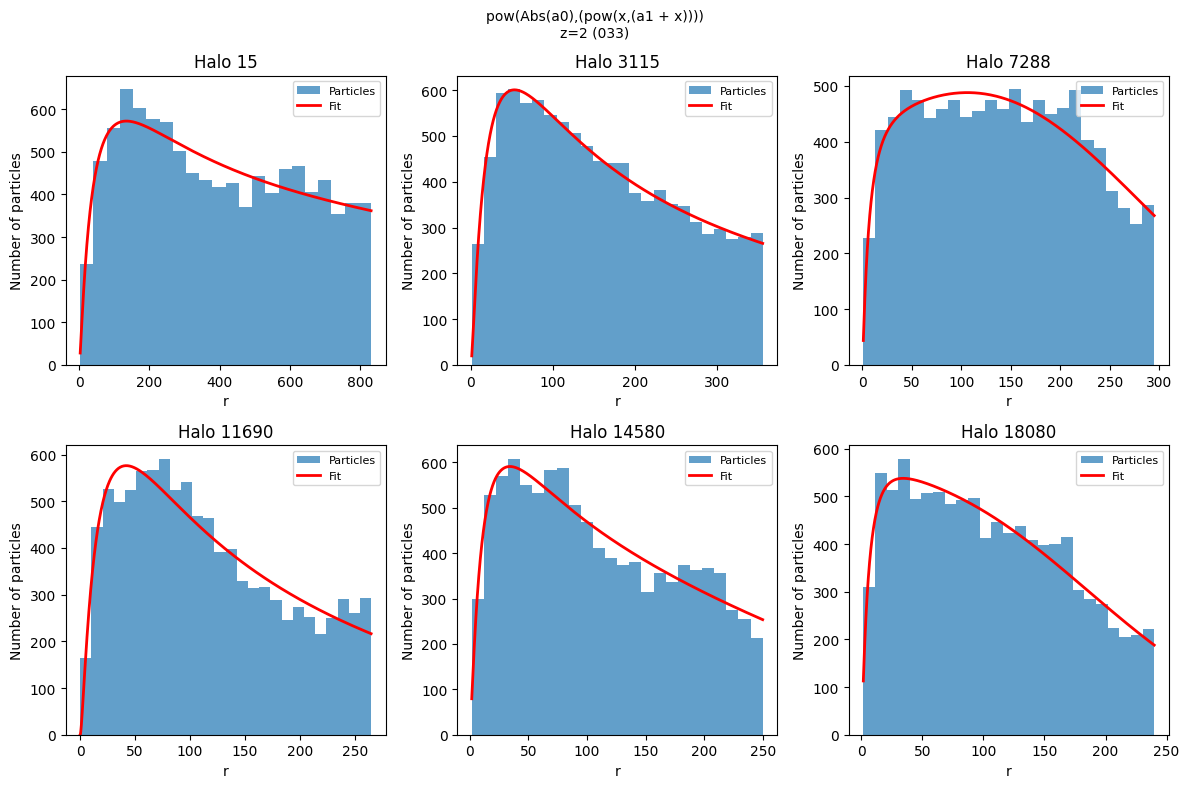

In [11]:
# --- Density profiles: data vs fit ---
import cdmprof

# Pick function by expression (partial match)
prof_expr = "pow(Abs(a0),(pow(x,(a1 + x))))"
# Pick snapshot index (0, 1, 2)
prof_snap = 2
# Number of halos to plot
n_plot = 6
# use_scaled_radius must match the fitting run
use_scaled_radius = True

# Particle files (same order as in the load cell)
particle_files = [
    Path("../data/tng_particles/particles_099.hdf5"),
    Path("../data/tng_particles/particles_050.hdf5"),
    Path("../data/tng_particles/particles_033.hdf5"),
]
result_patterns = [
    "fit_ext_maths_DM_compl{comp}_particles_099.hdf5",
    "fit_ext_maths_DM_compl{comp}_particles_050.hdf5",
    "fit_ext_maths_DM_compl{comp}_particles_033.hdf5",
]

# Resolve function
prof_comp, prof_fidx, prof_eq = None, None, None
for c in data["complexities"]:
    for fi, e in enumerate(data["equations"][c]):
        if prof_expr in e:
            prof_comp, prof_fidx, prof_eq = c, fi, e
            break
    if prof_comp is not None:
        break

if prof_comp is None:
    print(f"Expression '{prof_expr}' not found.")
else:
    print(f"Function: {prof_eq}")
    print(f"Complexity: {prof_comp}, func_idx: {prof_fidx}")

    # Load fitted params for this snapshot
    params_per_snap = load_function_params(
        Path("../results"), result_patterns, prof_comp, prof_fidx)

    if prof_snap not in params_per_snap:
        print(f"No results for snapshot {prof_snap}.")
    else:
        fit_params = params_per_snap[prof_snap]
        n_fitted = len(fit_params)
        print(f"Fitted {n_fitted} halos in {snap_labels[prof_snap]}")

        # Load particle data for this snapshot
        halos = cdmprof.data.load_from_hdf5(particle_files[prof_snap])

        # Build numpy evaluator
        parser = cdmprof.SympyParser(use_scaled_radius=use_scaled_radius)
        rho_func = parser.to_numpy(prof_eq)

        # Load halo_idx from HDF5 (sequential index, not halo ID)
        results_path = (Path("../results")
                        / result_patterns[prof_snap].format(comp=prof_comp))
        import h5py
        with h5py.File(results_path, "r") as f:
            fi_all = f["func_idx"][:]
            hi_all = f["halo_idx"][:]
        func_mask = fi_all == prof_fidx
        halo_indices = hi_all[func_mask]  # sequential indices

        # Convert sequential indices to halo IDs for particle lookup
        halo_ids = halos.halo_ids

        # Select halos to plot (evenly spaced)
        n_plot = min(n_plot, n_fitted)
        sel = np.linspace(0, n_fitted - 1, n_plot, dtype=int)

        nrows = (n_plot + 2) // 3
        fig, axes = plt.subplots(nrows, 3, figsize=(12, 4 * nrows))
        axes = np.atleast_2d(axes).flatten()

        for i, si in enumerate(sel):
            ax = axes[i]
            hidx = halo_indices[si]  # sequential index
            halo_id = halo_ids[hidx]  # actual halo ID
            params = fit_params[si]

            # Raw particle radii (indexed by halo ID)
            radii = halos[halo_id]

            # Histogram of particle counts
            counts, bin_edges, _ = ax.hist(
                radii, bins="auto", alpha=0.7, label="Particles")

            # Evaluate fitted profile
            r = np.logspace(np.log10(radii.min()), np.log10(radii.max()), 512)
            rho_fit = rho_func(r, *params)

            # Scale fit to particle counts:
            # rho * r^2 gives radial distribution, normalize to total particles
            rho_scaled = rho_fit * r**2
            rho_scaled = (rho_scaled / np.trapezoid(rho_scaled, r)
                          * len(radii) * np.mean(np.diff(bin_edges)))
            ax.plot(r, rho_scaled, 'r-', lw=2, label='Fit')

            ax.set_xlabel('r')
            ax.set_ylabel('Number of particles')
            ax.set_title(f'Halo {halo_id}')
            ax.legend(fontsize=8)

        # Hide unused axes
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f"{prof_eq}\n{snap_labels[prof_snap]}", fontsize=10)
        plt.tight_layout()
        plt.show()
